# 11. Change-Point Detection and Distribution Shift

The previous notebook focused on time-series anomaly detection: which timestamps are surprising given temporal context? This notebook asks a different question: **has the system changed?**

A point anomaly may last one hour. A change point means the data-generating process has moved into a new regime. Distribution shift means the population of inputs, labels, or relationships has changed relative to the reference period used to train or calibrate a model.

This distinction is crucial in decision systems. A single bad point may require incident review. A persistent distribution shift may require model monitoring, policy review, retraining, or a business explanation.

We will study:

1. Metric change points with CUSUM-style evidence accumulation.
2. Feature distribution shift with PSI and two-sample tests.
3. Multivariate shift detection with a classifier two-sample test.
4. Model-performance drift using delayed labels.
5. Decision rules that separate incident escalation from model-governance review.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Distinguish point anomalies, change points, covariate shift, prior shift, and concept drift.
2. Explain the logic of CUSUM as accumulated evidence for a persistent change.
3. Compute rolling population stability index and two-sample feature tests.
4. Use a classifier to detect multivariate distribution shift.
5. Diagnose when a deployed model's observed outcomes diverge from its expected outcomes.
6. Build a model-review decision memo from drift evidence rather than treating every shift as an incident.


In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.title_fontsize'] = 8
pd.set_option('display.max_columns', 120)

RANDOM_SEED = 51111
rng = np.random.default_rng(RANDOM_SEED)

PALETTE = {
    'observed': '#334155',
    'expected': '#2563eb',
    'cusum': '#dc2626',
    'shift': '#7c3aed',
    'covariate': '#059669',
    'concept': '#f97316',
    'baseline': '#94a3b8',
    'threshold': '#111827',
}

WALLET_LAUNCH_DATE = pd.Timestamp('2026-03-12')
FRAUD_ADAPTATION_DATE = pd.Timestamp('2026-04-01')


def shade_monitoring_periods(ax, end_date):
    """Carry out the shade monitoring periods step used in the 11. Change-Point Detection and Distribution Shift workflow.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    end_date : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    ax.axvspan(WALLET_LAUNCH_DATE, FRAUD_ADAPTATION_DATE, color=PALETTE['covariate'], alpha=0.08, zorder=0)
    ax.axvspan(FRAUD_ADAPTATION_DATE, end_date, color=PALETTE['concept'], alpha=0.08, zorder=0)


def add_shaded_period_legend(ax, loc='upper left'):
    """Carry out the add shaded period legend step used in the 11. Change-Point Detection and Distribution Shift workflow.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    loc : object
        The loc setting that controls the add shaded period legend calculation in this notebook.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    handles, labels = ax.get_legend_handles_labels()
    period_handles = [
        Patch(facecolor=PALETTE['covariate'], alpha=0.18, edgecolor='none', label='Wallet launch window (shaded)'),
        Patch(facecolor=PALETTE['concept'], alpha=0.18, edgecolor='none', label='Fraud adaptation window (shaded)'),
    ]
    ax.legend(handles + period_handles, labels + [handle.get_label() for handle in period_handles], loc=loc)


## 1. From Anomalies to Regime Changes

A point anomaly is a local surprise. A change point is a time at which the distribution changes. If $X_t$ denotes the data observed at time $t$, a simple change-point setup is

$$
X_t \sim P_0, \quad t < \tau,
$$

and

$$
X_t \sim P_1, \quad t \ge \tau.
$$

The unknown time $\tau$ is the change point. The operational question asks whether $P_0$ differs from $P_1$ and what decision should follow: suppress, investigate, retrain, change a policy, or roll back a deployment.


## 2. Types of Shift in Decision Systems

| Shift type | What changes? | Example | Typical response |
|---|---|---|---|
| Metric change point | A monitored KPI changes level, trend, or variance | Chargeback rate jumps after a fraud attack | Incident review or policy intervention |
| Covariate shift | The input distribution changes | More high-value transactions enter the system | Model validation and segment analysis |
| Prior probability shift | The base rate of the label changes | Fraud becomes more common while patterns stay similar | Threshold and capacity review |
| Concept drift | The relationship between inputs and outcome changes | Fraudsters adapt so old risk score underestimates risk | Model retraining or feature redesign |
| Data-quality shift | Measurement process changes | A logging field is truncated or delayed | Data pipeline fix before model action |

These shifts can coexist. A business launch may create covariate shift without harm. An adversarial behavior change may create both covariate shift and concept drift.


## 3. CUSUM as Evidence Accumulation

CUSUM is a classic sequential monitoring idea. Instead of alerting only when today's value is extreme, it accumulates evidence for a persistent change.

Let $r_t$ be a standardized residual. A one-sided upward CUSUM can be written as

$$
g_t = \max(0, g_{t-1} + r_t - k).
$$

An alarm is triggered when

$$
g_t > h.
$$

The parameter $k$ is a drift allowance: small residuals do not accumulate forever. The threshold $h$ controls alert sensitivity. Smaller $h$ detects earlier but creates more false alarms.


## 4. Distribution-Shift Scores

For a single feature, a two-sample test asks whether a reference window and monitoring window appear to come from the same distribution. A Kolmogorov-Smirnov statistic is

$$
D = \sup_x |F_{ref}(x) - F_{new}(x)|.
$$

Another common monitoring score is population stability index. If feature values are binned into groups $b = 1, \ldots, B$, then

$$
PSI = \sum_{b=1}^{B} (p_b - q_b) \log(p_b / q_b),
$$

where $p_b$ is the reference share in bin $b$ and $q_b$ is the new-window share.

PSI is not a formal proof of harmful drift. It is a practical magnitude score: which feature distributions moved enough to deserve review?


## 5. Synthetic Case: Marketplace Payment-Risk Monitoring

Imagine a marketplace with a deployed fraud-risk model. The model scores payment attempts and helps decide which transactions receive friction, review, or approval.

The business changes in two stages:

1. A new mobile-wallet promotion changes the transaction mix. That is mostly covariate shift.
2. Later, fraudsters adapt. The same features become less predictive, and observed chargebacks exceed model expectations. That is concept drift.

The monitoring team needs to decide whether to escalate an incident, recalibrate thresholds, retrain the model, or annotate a benign business change.


In [2]:
# Section focus: 5. Synthetic Case: Marketplace Payment-Risk Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_payment_risk(seed=RANDOM_SEED, days=125):
    """Create a simulated payment risk data set for the 11. Change-Point Detection and Distribution Shift case study.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    days : object
        Number of days represented in the simulated monitoring window.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    start = pd.Timestamp('2026-01-01')
    rows = []
    for day in range(days):
        date = start + pd.Timedelta(days=day)
        dow = date.dayofweek
        weekly = 1.08 if dow in [4, 5] else (0.90 if dow == 6 else 1.0)
        launch = day >= 70
        adaptation = day >= 90
        n = int(rng.poisson((820 + 2.0 * day) * weekly * (1.18 if launch else 1.0)))
        for _ in range(n):
            high_value_mix = 0.14 + 0.12 * launch + 0.03 * np.sin(day / 8)
            promo_mix = 0.10 + 0.18 * launch
            new_account_mix = 0.23 + 0.06 * launch + 0.04 * adaptation
            high_value = rng.binomial(1, np.clip(high_value_mix, 0.02, 0.55))
            promo = rng.binomial(1, np.clip(promo_mix, 0.02, 0.55))
            new_account = rng.binomial(1, np.clip(new_account_mix, 0.03, 0.65))
            mobile_wallet = rng.binomial(1, 0.12 + 0.42 * launch)
            cross_border = rng.binomial(1, 0.11 + 0.05 * high_value + 0.04 * adaptation)
            account_age_days = rng.gamma(2.4, 75) * (1 - new_account) + rng.gamma(1.4, 5) * new_account
            account_age_days = np.clip(account_age_days, 0, 800)
            order_value = rng.lognormal(3.55 + 0.50 * high_value + 0.25 * promo + 0.16 * launch, 0.48)
            order_value = np.clip(order_value, 8, 950)
            device_risk = np.clip(rng.normal(31 + 17 * new_account + 11 * cross_border - 6 * mobile_wallet + 5 * adaptation, 13), 0, 100)
            velocity_24h = rng.poisson(1.4 + 1.7 * new_account + 0.7 * promo + 1.0 * adaptation)
            discount_rate = np.clip(rng.beta(2.0 + 3.0 * promo, 12) + 0.09 * launch * promo, 0, 0.75)
            shipping_distance = np.clip(rng.gamma(2.2, 90) + 90 * cross_border + 45 * high_value, 5, 900)

            # Old model was trained before launch/adaptation and overweights visible device risk.
            old_logit = (
                -4.15
                + 0.020 * device_risk
                + 0.235 * velocity_24h
                + 0.62 * new_account
                + 0.38 * cross_border
                + 0.0022 * order_value
                + 0.75 * discount_rate
                - 0.0028 * account_age_days
                + 0.22 * high_value
            )
            model_score = 1 / (1 + np.exp(-old_logit))

            true_logit = old_logit
            if launch:
                true_logit += -0.18 * mobile_wallet + 0.12 * promo
            if adaptation:
                true_logit += 0.85 * mobile_wallet + 0.55 * promo + 0.35 * high_value - 0.011 * device_risk
            true_logit += rng.normal(0, 0.18)
            chargeback = rng.binomial(1, 1 / (1 + np.exp(-true_logit)))

            friction = rng.binomial(1, np.clip(0.08 + 0.55 * model_score + 0.06 * high_value, 0, 0.95))
            approved = rng.binomial(1, np.clip(0.96 - 0.40 * model_score - 0.07 * friction + 0.04 * mobile_wallet, 0.35, 0.995))

            rows.append({
                'date': date,
                'day': day,
                'dow': dow,
                'order_value': order_value,
                'account_age_days': account_age_days,
                'device_risk': device_risk,
                'velocity_24h': velocity_24h,
                'discount_rate': discount_rate,
                'shipping_distance': shipping_distance,
                'new_account': new_account,
                'mobile_wallet': mobile_wallet,
                'promo': promo,
                'high_value': high_value,
                'cross_border': cross_border,
                'model_score': model_score,
                'friction': friction,
                'approved': approved,
                'chargeback': chargeback,
                'period': 'fraud_adaptation' if adaptation else ('wallet_launch' if launch else 'baseline'),
            })
    return pd.DataFrame(rows)

transactions = simulate_payment_risk()
reference = transactions[transactions['day'] < 55].copy()
calibration = transactions[(transactions['day'] >= 55) & (transactions['day'] < 70)].copy()
monitor = transactions[transactions['day'] >= 70].copy()

split_summary = transactions.assign(split=np.select(
    [transactions['day'] < 55, transactions['day'] < 70],
    ['reference', 'calibration'],
    default='monitoring',
)).groupby('split').agg(
    rows=('date', 'size'),
    start=('date', 'min'),
    end=('date', 'max'),
    chargeback_rate=('chargeback', 'mean'),
    mean_model_score=('model_score', 'mean'),
    mobile_wallet_share=('mobile_wallet', 'mean'),
    promo_share=('promo', 'mean'),
).reset_index()

smart_display(split_summary.style.format({
    'chargeback_rate': '{:.2%}',
    'mean_model_score': '{:.2%}',
    'mobile_wallet_share': '{:.1%}',
    'promo_share': '{:.1%}',
}))


,split,rows,start,end,chargeback_rate,mean_model_score,mobile_wallet_share,promo_share
0,calibration,14032,2026-02-25 00:00:00,2026-03-11 00:00:00,7.28%,7.43%,12.1%,9.8%
1,monitoring,66301,2026-03-12 00:00:00,2026-05-05 00:00:00,12.79%,11.26%,53.9%,28.2%
2,reference,48514,2026-01-01 00:00:00,2026-02-24 00:00:00,7.41%,7.26%,12.2%,10.2%


The reference period represents the distribution used to train and calibrate the existing risk model. The wallet launch changes the input population. The later fraud adaptation changes the relationship between inputs and chargebacks.

This gives us a useful teaching distinction: a distribution shift can be benign, harmful, or merely a sign that the model is now being used outside its original design envelope.


## 6. Daily Monitoring Table

We aggregate daily outcomes and compare observed chargeback rate with expected chargeback rate from the old model.

A simple model residual is

$$
r_t = observed\_rate_t - expected\_rate_t.
$$

If the model is calibrated and the population is stable, this residual should fluctuate around zero. Persistent positive residuals suggest the model is underestimating risk.


In [3]:
# Section focus: 6. Daily Monitoring Table.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

daily = transactions.groupby('date').agg(
    day=('day', 'first'),
    transactions=('date', 'size'),
    observed_chargeback_rate=('chargeback', 'mean'),
    expected_chargeback_rate=('model_score', 'mean'),
    approval_rate=('approved', 'mean'),
    friction_rate=('friction', 'mean'),
    mean_order_value=('order_value', 'mean'),
    mean_device_risk=('device_risk', 'mean'),
    mobile_wallet_share=('mobile_wallet', 'mean'),
    promo_share=('promo', 'mean'),
    period=('period', lambda s: s.mode().iat[0]),
).reset_index()
daily['model_residual'] = daily['observed_chargeback_rate'] - daily['expected_chargeback_rate']

daily_summary = daily.groupby('period').agg(
    days=('date', 'size'),
    mean_transactions=('transactions', 'mean'),
    observed_chargeback_rate=('observed_chargeback_rate', 'mean'),
    expected_chargeback_rate=('expected_chargeback_rate', 'mean'),
    mean_residual=('model_residual', 'mean'),
    mobile_wallet_share=('mobile_wallet_share', 'mean'),
    promo_share=('promo_share', 'mean'),
).reset_index()

smart_display(daily_summary.style.format({
    'mean_transactions': '{:.0f}',
    'observed_chargeback_rate': '{:.2%}',
    'expected_chargeback_rate': '{:.2%}',
    'mean_residual': '{:.2%}',
    'mobile_wallet_share': '{:.1%}',
    'promo_share': '{:.1%}',
}))


,period,days,mean_transactions,observed_chargeback_rate,expected_chargeback_rate,mean_residual,mobile_wallet_share,promo_share
0,baseline,70,894,7.37%,7.29%,0.07%,12.2%,10.1%
1,fraud_adaptation,35,1226,15.13%,12.58%,2.55%,54.0%,28.1%
2,wallet_launch,20,1169,8.46%,8.82%,-0.36%,53.8%,28.3%


This table gives a first model-risk signal. If expected and observed rates move together, the model may remain calibrated despite population changes. If observed outcomes rise while expected risk does not, the relationship between features and outcome may have shifted.

For Daily Monitoring Table, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


## 7. CUSUM on Model Residuals

We first monitor the daily residual between observed and expected chargeback rates. This is a performance-drift signal rather than an input-shift signal.

We estimate the baseline residual mean and scale from the reference and calibration periods, then accumulate positive residual evidence using CUSUM.


,baseline_residual_mean,baseline_residual_sd,drift_allowance_k,decision_threshold_h,first_cusum_alert
0,0.075%,0.788%,0.35,6.0,2026-04-03 00:00:00


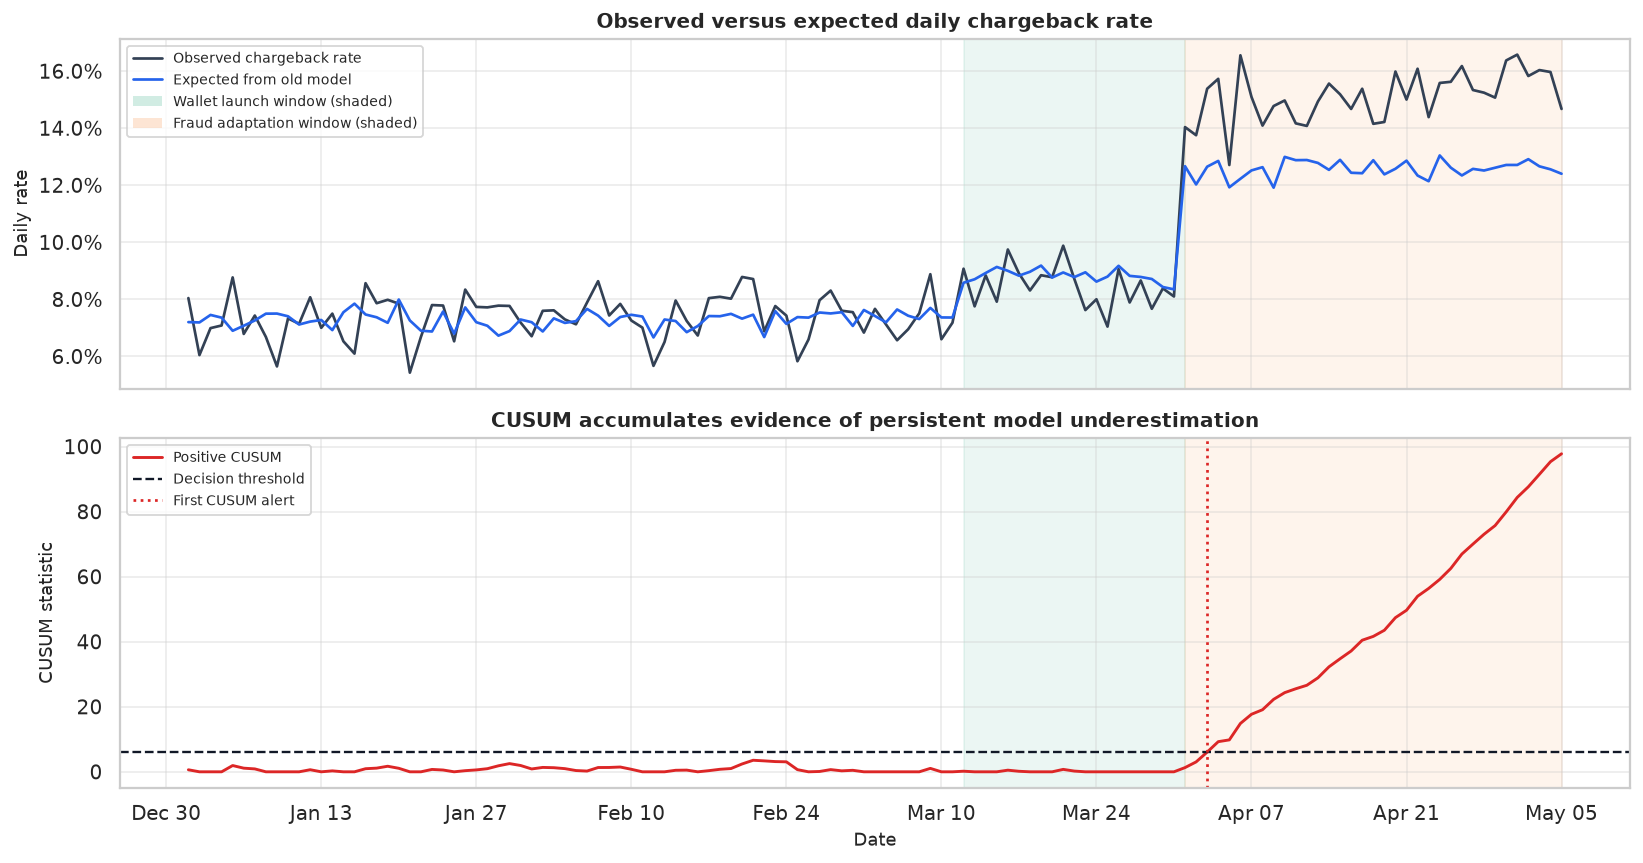

In [4]:
# Section focus: 7. CUSUM on Model Residuals.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

baseline_days = daily[daily['day'] < 70].copy()
mu0 = baseline_days['model_residual'].mean()
sigma0 = baseline_days['model_residual'].std(ddof=1)
sigma0 = max(sigma0, 0.001)

daily['standardized_residual'] = (daily['model_residual'] - mu0) / sigma0
k = 0.35
h = 6.0
g = []
current = 0.0
for value in daily['standardized_residual']:
    current = max(0.0, current + value - k)
    g.append(current)
daily['cusum_positive'] = g
daily['cusum_alert'] = daily['cusum_positive'] > h
first_cusum_alert = daily.loc[daily['cusum_alert'], 'date'].min() if daily['cusum_alert'].any() else pd.NaT

cusum_setup = pd.DataFrame([
    {
        'baseline_residual_mean': mu0,
        'baseline_residual_sd': sigma0,
        'drift_allowance_k': k,
        'decision_threshold_h': h,
        'first_cusum_alert': first_cusum_alert,
    }
])
smart_display(cusum_setup.style.format({
    'baseline_residual_mean': '{:.3%}',
    'baseline_residual_sd': '{:.3%}',
    'drift_allowance_k': '{:.2f}',
    'decision_threshold_h': '{:.1f}',
}))

fig, axes = plt.subplots(2, 1, figsize=(12.8, 6.8), sharex=True)
axes[0].plot(daily['date'], daily['observed_chargeback_rate'], color=PALETTE['observed'], linewidth=1.5, label='Observed chargeback rate')
axes[0].plot(daily['date'], daily['expected_chargeback_rate'], color=PALETTE['expected'], linewidth=1.5, label='Expected from old model')
axes[0].set_ylabel('Daily rate')
axes[0].yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
axes[0].set_title('Observed versus expected daily chargeback rate')
add_shaded_period_legend(axes[0], loc='upper left')

axes[1].plot(daily['date'], daily['cusum_positive'], color=PALETTE['cusum'], linewidth=1.6, label='Positive CUSUM')
axes[1].axhline(h, color=PALETTE['threshold'], linestyle='--', linewidth=1.3, label='Decision threshold')
if pd.notna(first_cusum_alert):
    axes[1].axvline(first_cusum_alert, color=PALETTE['cusum'], linestyle=':', linewidth=1.5, label='First CUSUM alert')
for ax in axes:
    shade_monitoring_periods(ax, daily['date'].max())
    ax.grid(True, alpha=0.35)
axes[1].set_ylabel('CUSUM statistic')
axes[1].set_xlabel('Date')
axes[1].set_title('CUSUM accumulates evidence of persistent model underestimation')
axes[1].legend(loc='upper left')
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()


CUSUM is useful because it distinguishes persistent drift from one noisy day. The statistic does not reset to zero unless the evidence weakens. That makes it sensitive to slow model degradation.

However, CUSUM on outcomes is delayed by label availability. In fraud, chargebacks may arrive days or weeks after the transaction. Input-shift monitoring can warn earlier, but outcome monitoring tells us whether the shift is actually harming model performance.


## 8. Rolling Feature Shift: PSI and KS Statistics

Now we monitor the input distribution. We compare each rolling seven-day monitoring window against the reference period.

The population stability index is useful for magnitude and feature ranking. The KS statistic is useful as a distributional distance for continuous features. Neither one proves business harm. They answer: **what moved?**


,end_date,total_psi,max_ks,max_ks_feature
0,2026-03-18 00:00:00,1.745,0.206,order_value
1,2026-03-19 00:00:00,1.767,0.212,order_value
2,2026-03-20 00:00:00,1.776,0.213,order_value
3,2026-03-21 00:00:00,1.735,0.213,order_value
4,2026-03-22 00:00:00,1.731,0.211,order_value


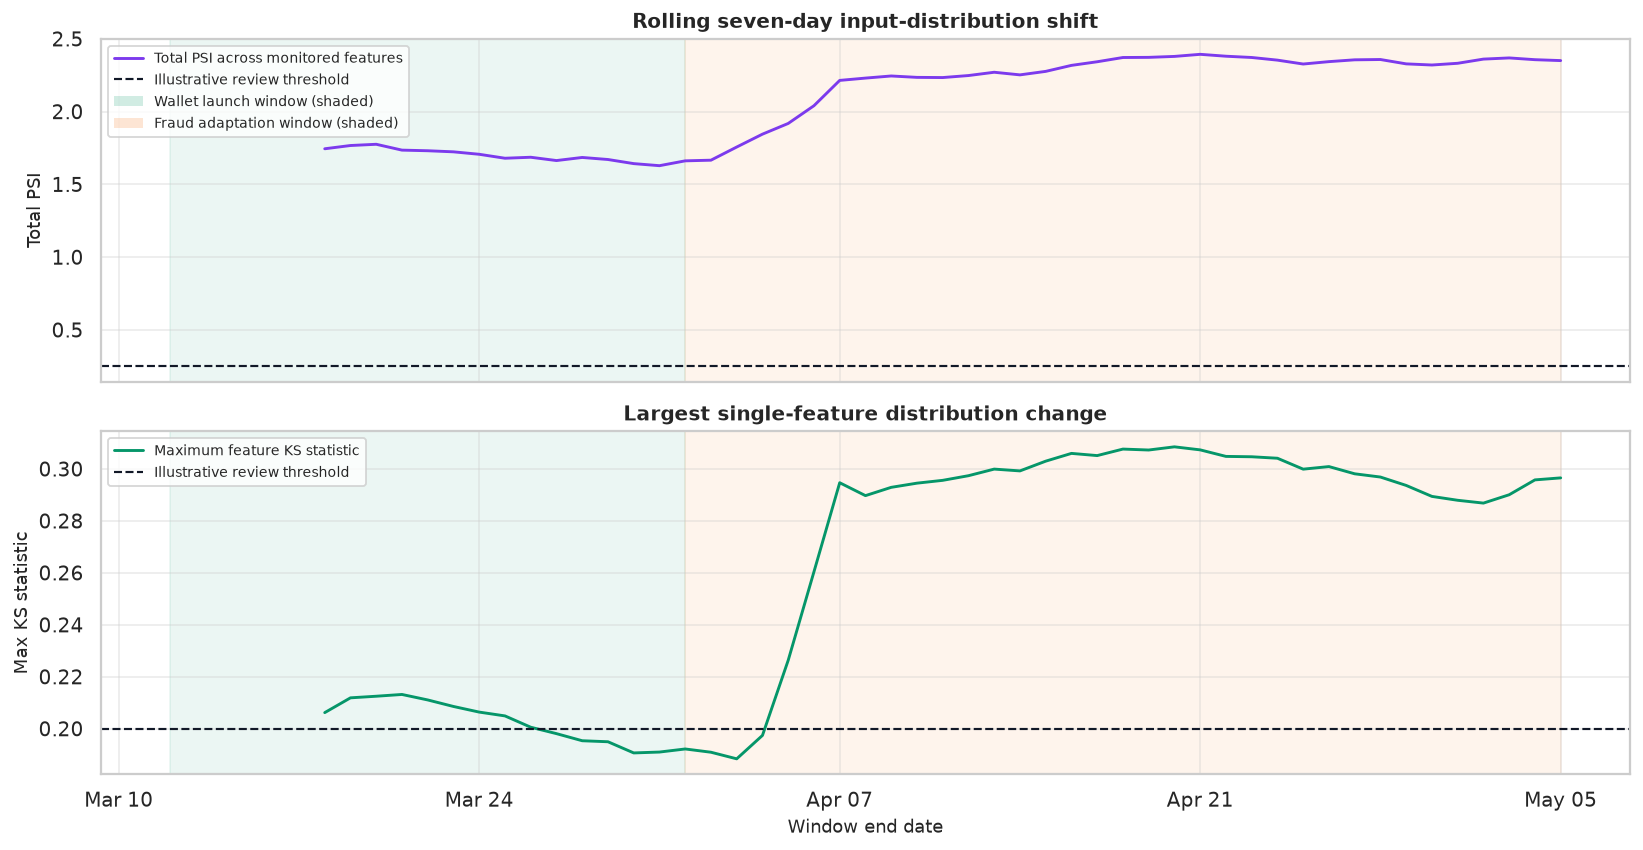

In [5]:
# Section focus: 8. Rolling Feature Shift: PSI and KS Statistics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

FEATURES = [
    'order_value',
    'account_age_days',
    'device_risk',
    'velocity_24h',
    'discount_rate',
    'shipping_distance',
    'mobile_wallet',
    'promo',
    'high_value',
    'cross_border',
]
continuous_features = ['order_value', 'account_age_days', 'device_risk', 'velocity_24h', 'discount_rate', 'shipping_distance']


def make_bins(ref_values, n_bins=10):
    """Construct the bins helper used in the 11. Change-Point Detection and Distribution Shift workflow.
    
    Parameters
    ----------
    ref_values : object
        The ref values setting that controls the bins calculation in this notebook.
    n_bins : object
        Count or size setting for the bins calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the bins calculation and reused by later cells.
    """
    quantiles = np.quantile(ref_values, np.linspace(0, 1, n_bins + 1))
    bins = np.unique(quantiles)
    if len(bins) < 3:
        lo, hi = np.min(ref_values), np.max(ref_values)
        bins = np.linspace(lo - 1e-6, hi + 1e-6, n_bins + 1)
    bins[0] = -np.inf
    bins[-1] = np.inf
    return bins


def psi_score(ref_values, new_values, bins):
    """Carry out the psi score step used in the 11. Change-Point Detection and Distribution Shift workflow.
    
    Parameters
    ----------
    ref_values : object
        The ref values setting that controls the psi score calculation in this notebook.
    new_values : object
        The new values setting that controls the psi score calculation in this notebook.
    bins : object
        The bins setting that controls the psi score calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the psi score calculation.
    """
    ref_counts, _ = np.histogram(ref_values, bins=bins)
    new_counts, _ = np.histogram(new_values, bins=bins)
    eps = 1e-5
    p = ref_counts / max(ref_counts.sum(), 1)
    q = new_counts / max(new_counts.sum(), 1)
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    return float(np.sum((p - q) * np.log(p / q)))

feature_bins = {feature: make_bins(reference[feature].to_numpy()) for feature in FEATURES}
window_rows = []
for end_day in range(76, transactions['day'].max() + 1):
    window = transactions[(transactions['day'] > end_day - 7) & (transactions['day'] <= end_day)]
    if len(window) < 100:
        continue
    row = {'end_day': end_day, 'end_date': transactions.loc[transactions['day'].eq(end_day), 'date'].iloc[0]}
    total_psi = 0.0
    max_ks = 0.0
    max_ks_feature = None
    for feature in FEATURES:
        psi = psi_score(reference[feature].to_numpy(), window[feature].to_numpy(), feature_bins[feature])
        row[f'psi_{feature}'] = psi
        total_psi += psi
        if feature in continuous_features:
            ks = ks_2samp(reference[feature].to_numpy(), window[feature].to_numpy()).statistic
            row[f'ks_{feature}'] = ks
            if ks > max_ks:
                max_ks = ks
                max_ks_feature = feature
    row['total_psi'] = total_psi
    row['max_ks'] = max_ks
    row['max_ks_feature'] = max_ks_feature
    window_rows.append(row)
shift_windows = pd.DataFrame(window_rows)

smart_display(shift_windows[['end_date', 'total_psi', 'max_ks', 'max_ks_feature']].head().style.format({'total_psi': '{:.3f}', 'max_ks': '{:.3f}'}))

fig, axes = plt.subplots(2, 1, figsize=(12.8, 6.7), sharex=True)
axes[0].plot(shift_windows['end_date'], shift_windows['total_psi'], color=PALETTE['shift'], linewidth=1.6, label='Total PSI across monitored features')
axes[0].axhline(0.25, color=PALETTE['threshold'], linestyle='--', linewidth=1.2, label='Illustrative review threshold')
axes[0].set_ylabel('Total PSI')
axes[0].set_title('Rolling seven-day input-distribution shift')
add_shaded_period_legend(axes[0], loc='upper left')
axes[1].plot(shift_windows['end_date'], shift_windows['max_ks'], color=PALETTE['covariate'], linewidth=1.6, label='Maximum feature KS statistic')
axes[1].axhline(0.20, color=PALETTE['threshold'], linestyle='--', linewidth=1.2, label='Illustrative review threshold')
axes[1].set_ylabel('Max KS statistic')
axes[1].set_xlabel('Window end date')
axes[1].set_title('Largest single-feature distribution change')
axes[1].legend(loc='upper left')
for ax in axes:
    shade_monitoring_periods(ax, shift_windows['end_date'].max())
    ax.grid(True, alpha=0.35)
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()


The shift scores move before the outcome-based CUSUM becomes decisive. That is exactly why input monitoring is valuable: it detects that the model is operating on a different population.

But input shift alone does not tell us whether the model is wrong. A benign wallet launch can create large covariate shift while improving customer experience. The decision should be model review and segment monitoring, not automatic incident escalation.


## 9. Which Features Shifted?

A single shift score is not enough. The next question is diagnostic: **which features changed, and does that change matter for the decision policy?**

We compare feature-level PSI in a wallet-launch window and a fraud-adaptation window.


,feature,psi,reference_mean,window_mean,window
0,mobile_wallet,0.891,0.122,0.540,Wallet launch
1,order_value,0.253,43.915,58.381,Wallet launch
2,promo,0.229,0.102,0.284,Wallet launch
3,discount_rate,0.197,0.158,0.211,Wallet launch
4,high_value,0.097,0.140,0.263,Wallet launch
5,velocity_24h,0.025,1.854,2.109,Wallet launch
10,mobile_wallet,0.902,0.122,0.543,Fraud adaptation
11,velocity_24h,0.525,1.854,3.141,Fraud adaptation
12,order_value,0.234,43.915,57.699,Fraud adaptation
13,promo,0.221,0.102,0.280,Fraud adaptation


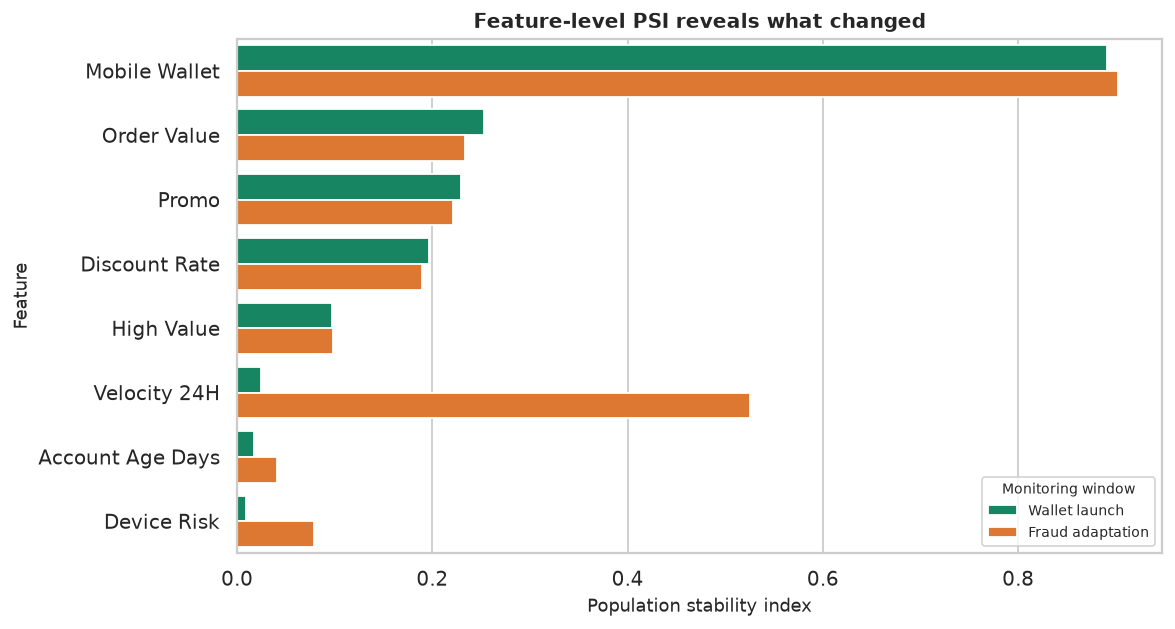

In [6]:
# Section focus: 9. Which Features Shifted?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def feature_psi_for_window(start_day, end_day):
    """Carry out the feature psi for window step used in the 11. Change-Point Detection and Distribution Shift workflow.
    
    Parameters
    ----------
    start_day : object
        The start day setting that controls the feature psi for window calculation in this notebook.
    end_day : object
        The end day setting that controls the feature psi for window calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the feature psi for window calculation and reused by later cells.
    """
    window = transactions[(transactions['day'] >= start_day) & (transactions['day'] <= end_day)]
    rows = []
    for feature in FEATURES:
        rows.append({
            'feature': feature,
            'psi': psi_score(reference[feature].to_numpy(), window[feature].to_numpy(), feature_bins[feature]),
            'reference_mean': reference[feature].mean(),
            'window_mean': window[feature].mean(),
        })
    return pd.DataFrame(rows).sort_values('psi', ascending=False)

wallet_psi = feature_psi_for_window(72, 84).assign(window='Wallet launch')
adaptation_psi = feature_psi_for_window(95, 112).assign(window='Fraud adaptation')
feature_psi_table = pd.concat([wallet_psi, adaptation_psi], ignore_index=True)

smart_display(feature_psi_table.groupby('window').head(6).style.format({
    'psi': '{:.3f}',
    'reference_mean': '{:.3f}',
    'window_mean': '{:.3f}',
}))

fig, ax = plt.subplots(figsize=(9.2, 5.0))
plot_psi = feature_psi_table.groupby('window').head(8).copy()
plot_psi['feature_label'] = plot_psi['feature'].str.replace('_', ' ').str.title()
sns.barplot(data=plot_psi, y='feature_label', x='psi', hue='window', palette=[PALETTE['covariate'], PALETTE['concept']], ax=ax)
ax.set_xlabel('Population stability index')
ax.set_ylabel('Feature')
ax.set_title('Feature-level PSI reveals what changed')
ax.legend(title='Monitoring window', loc='lower right')
plt.tight_layout()
plt.show()


Feature-level PSI turns a vague drift alert into an investigation plan. If `mobile_wallet`, `promo`, and `order_value` shift during the launch, the likely explanation is business mix. If later `device_risk`, `velocity_24h`, or high-value patterns shift while observed chargebacks rise, the investigation changes direction.

This is where domain knowledge matters. Distribution shift may be benign, but the old validation evidence may no longer apply cleanly.


## 10. Multivariate Shift with a Classifier Two-Sample Test

A classifier two-sample test reframes distribution shift as a prediction problem. Label reference examples as 0 and current-window examples as 1. If a classifier can reliably tell them apart, the distributions differ.

For a balanced reference-current test set:

$$
AUC \approx 0.5
$$

means little detectable shift, while values closer to 1 indicate stronger separability.

This approach can capture feature interactions that univariate tests miss, but it also requires careful sampling and guardrails against overfitting.


,end_day,end_date,classifier_shift_auc
0,76,2026-03-18 00:00:00,0.752
1,79,2026-03-21 00:00:00,0.790
2,82,2026-03-24 00:00:00,0.809
3,85,2026-03-27 00:00:00,0.816
4,88,2026-03-30 00:00:00,0.788


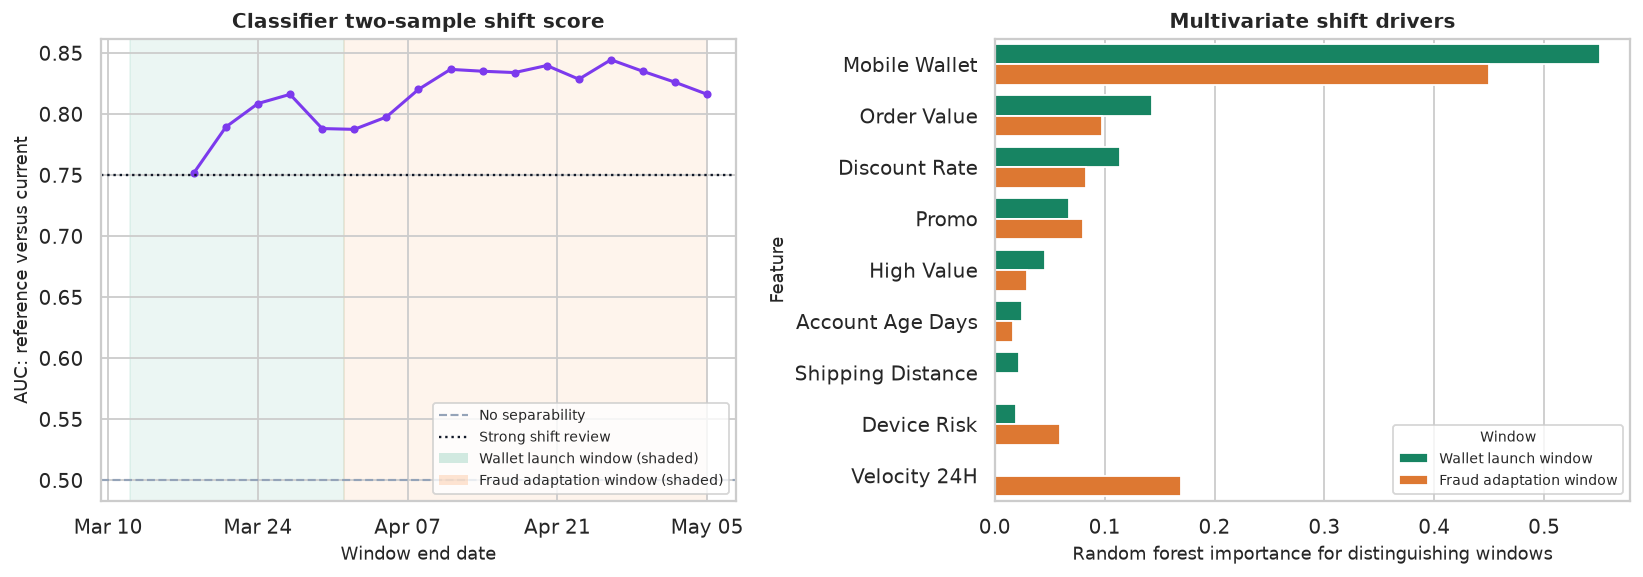

In [7]:
# Section focus: 10. Multivariate Shift with a Classifier Two-Sample Test.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def classifier_shift_auc(window, features=FEATURES, max_rows=2500, seed=RANDOM_SEED):
    """Carry out the classifier shift auc step used in the 11. Change-Point Detection and Distribution Shift workflow.
    
    Parameters
    ----------
    window : object
        Time window or row window over which the diagnostic is computed.
    features : object
        Feature column names or feature matrix used by the model.
    max_rows : object
        Maximum number of rows shown in a rendered table or diagnostic display.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    ref = reference[features].sample(n=min(max_rows, len(reference)), random_state=seed)
    cur = window[features].sample(n=min(max_rows, len(window)), random_state=seed + 1)
    X = pd.concat([ref, cur], ignore_index=True)
    y = np.r_[np.zeros(len(ref)), np.ones(len(cur))]
    if len(np.unique(y)) < 2:
        return np.nan
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, stratify=y, random_state=seed)
    clf = RandomForestClassifier(
        n_estimators=120,
        max_depth=5,
        min_samples_leaf=25,
        random_state=seed,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
    return auc, importances

auc_rows = []
importance_rows = []
for end_day in range(76, transactions['day'].max() + 1, 3):
    window = transactions[(transactions['day'] > end_day - 10) & (transactions['day'] <= end_day)]
    auc, importances = classifier_shift_auc(window, seed=RANDOM_SEED + end_day)
    end_date = transactions.loc[transactions['day'].eq(end_day), 'date'].iloc[0]
    auc_rows.append({'end_day': end_day, 'end_date': end_date, 'classifier_shift_auc': auc})
    if end_day in [82, 106]:
        tmp = importances.head(8).reset_index()
        tmp.columns = ['feature', 'importance']
        tmp['window_end_day'] = end_day
        tmp['window_end_date'] = end_date
        importance_rows.append(tmp)
classifier_shift = pd.DataFrame(auc_rows)
classifier_importance = pd.concat(importance_rows, ignore_index=True)

smart_display(classifier_shift.head().style.format({'classifier_shift_auc': '{:.3f}'}))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
axes[0].plot(classifier_shift['end_date'], classifier_shift['classifier_shift_auc'], color=PALETTE['shift'], linewidth=1.7, marker='o', markersize=3.5)
axes[0].axhline(0.5, color=PALETTE['baseline'], linestyle='--', linewidth=1.2, label='No separability')
axes[0].axhline(0.75, color=PALETTE['threshold'], linestyle=':', linewidth=1.3, label='Strong shift review')
shade_monitoring_periods(axes[0], classifier_shift['end_date'].max())
axes[0].set_ylabel('AUC: reference versus current')
axes[0].set_xlabel('Window end date')
axes[0].set_title('Classifier two-sample shift score')
add_shaded_period_legend(axes[0], loc='lower right')
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plot_imp = classifier_importance.copy()
plot_imp['feature_label'] = plot_imp['feature'].str.replace('_', ' ').str.title()
plot_imp['window'] = plot_imp['window_end_day'].map({82: 'Wallet launch window', 106: 'Fraud adaptation window'})
sns.barplot(data=plot_imp, y='feature_label', x='importance', hue='window', palette=[PALETTE['covariate'], PALETTE['concept']], ax=axes[1])
axes[1].set_xlabel('Random forest importance for distinguishing windows')
axes[1].set_ylabel('Feature')
axes[1].set_title('Multivariate shift drivers')
axes[1].legend(title='Window', loc='lower right')
plt.tight_layout()
plt.show()


The classifier shift score asks a simple question: can we distinguish current transactions from reference transactions? If yes, the old validation results deserve skepticism.

The feature importance chart should not be read as causal attribution. It is a diagnostic map of what helped separate the current population from the reference population. It tells the monitoring team where to inspect, not why the business changed.


## 11. Model Performance Drift with Delayed Labels

When labels become available, the monitoring team should check whether model ranking and calibration still hold.

We compute rolling seven-day model quality:

- chargeback rate,
- average predicted risk,
- residual between observed and expected rates,
- ROC AUC when both classes are present,
- average precision when both classes are present.

This is the bridge from unsupervised drift monitoring to supervised model governance.


,end_day,end_date,rows,observed_chargeback_rate,expected_chargeback_rate,residual,roc_auc,average_precision
87,117,2026-04-28 00:00:00,17051,15.22%,12.58%,2.64%,0.756,0.382
88,118,2026-04-29 00:00:00,17100,15.21%,12.56%,2.65%,0.760,0.389
89,119,2026-04-30 00:00:00,17247,15.34%,12.58%,2.75%,0.759,0.388
90,120,2026-05-01 00:00:00,17350,15.43%,12.60%,2.83%,0.759,0.390
91,121,2026-05-02 00:00:00,17338,15.56%,12.61%,2.95%,0.760,0.395
92,122,2026-05-03 00:00:00,17403,15.67%,12.62%,3.05%,0.763,0.403
93,123,2026-05-04 00:00:00,17423,15.67%,12.62%,3.05%,0.764,0.401
94,124,2026-05-05 00:00:00,17511,15.64%,12.59%,3.05%,0.764,0.401


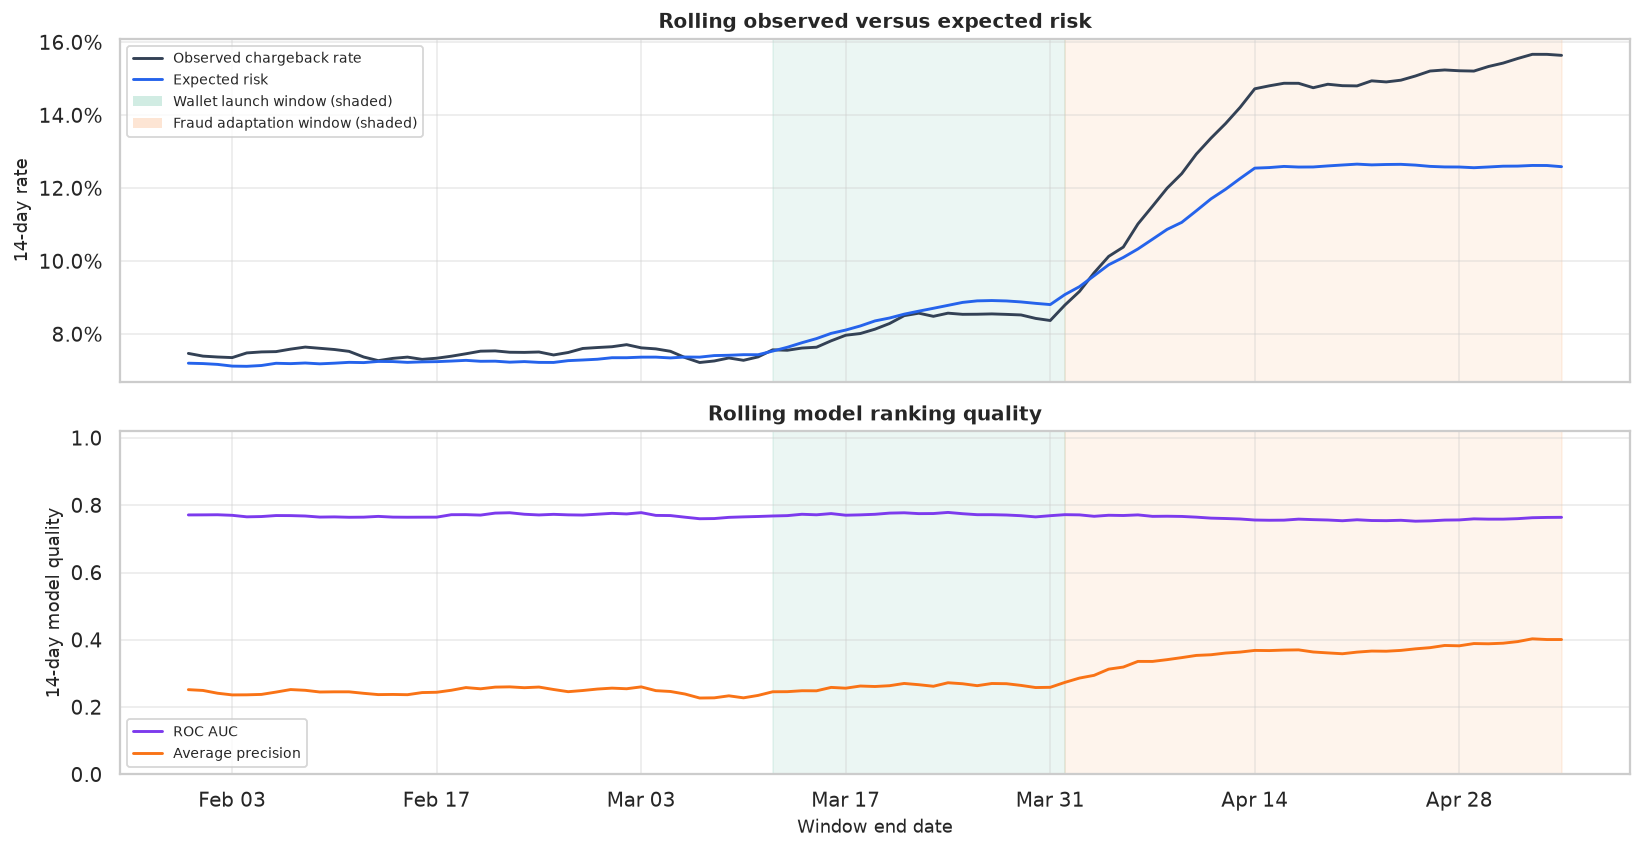

In [8]:
# Section focus: 11. Model Performance Drift with Delayed Labels.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

perf_rows = []
for end_day in range(30, transactions['day'].max() + 1):
    window = transactions[(transactions['day'] > end_day - 14) & (transactions['day'] <= end_day)]
    if len(window) < 200:
        continue
    y = window['chargeback'].to_numpy()
    score = window['model_score'].to_numpy()
    auc = roc_auc_score(y, score) if len(np.unique(y)) == 2 else np.nan
    ap = average_precision_score(y, score) if len(np.unique(y)) == 2 else np.nan
    perf_rows.append({
        'end_day': end_day,
        'end_date': transactions.loc[transactions['day'].eq(end_day), 'date'].iloc[0],
        'rows': len(window),
        'observed_chargeback_rate': y.mean(),
        'expected_chargeback_rate': score.mean(),
        'residual': y.mean() - score.mean(),
        'roc_auc': auc,
        'average_precision': ap,
    })
perf = pd.DataFrame(perf_rows)

smart_display(perf.tail(8).style.format({
    'observed_chargeback_rate': '{:.2%}',
    'expected_chargeback_rate': '{:.2%}',
    'residual': '{:.2%}',
    'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}',
}))

fig, axes = plt.subplots(2, 1, figsize=(12.8, 6.7), sharex=True)
axes[0].plot(perf['end_date'], perf['observed_chargeback_rate'], color=PALETTE['observed'], linewidth=1.6, label='Observed chargeback rate')
axes[0].plot(perf['end_date'], perf['expected_chargeback_rate'], color=PALETTE['expected'], linewidth=1.6, label='Expected risk')
axes[0].set_ylabel('14-day rate')
axes[0].yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
axes[0].set_title('Rolling observed versus expected risk')
add_shaded_period_legend(axes[0], loc='upper left')
axes[1].plot(perf['end_date'], perf['roc_auc'], color=PALETTE['shift'], linewidth=1.6, label='ROC AUC')
axes[1].plot(perf['end_date'], perf['average_precision'], color=PALETTE['concept'], linewidth=1.6, label='Average precision')
axes[1].set_ylabel('14-day model quality')
axes[1].set_xlabel('Window end date')
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Rolling model ranking quality')
axes[1].legend(loc='lower left')
for ax in axes:
    shade_monitoring_periods(ax, perf['end_date'].max())
    ax.grid(True, alpha=0.35)
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()


Input shift may be visible quickly, but performance drift requires labels. When labels arrive, we can separate benign covariate shift from harmful concept drift.

If ranking quality remains strong but residuals rise, threshold recalibration may be enough. If ranking quality degrades, the old feature relationship is breaking and model redesign becomes more likely.


## 12. Combining Evidence into Review States

A useful monitoring dashboard separates evidence types:

1. **Population moved:** input shift scores are high.
2. **Model underestimates risk:** outcome residual CUSUM alerts.
3. **Model ranking degrades:** rolling AUC or average precision falls.
4. **Known business event:** shift is expected and annotated.

We convert those signals into simple review states.


,period,recommended_state,days,first_day,last_day,mean_total_psi,mean_classifier_auc,mean_model_residual,mean_roc_auc
0,baseline,Routine monitoring,70,2026-01-01 00:00:00,2026-03-11 00:00:00,not computed,not computed,0.07%,0.769
1,fraud_adaptation,Model-risk review: shift plus performance evidence,33,2026-04-03 00:00:00,2026-05-05 00:00:00,2.268,0.827,2.61%,0.760
2,fraud_adaptation,Population-shift review: inspect segments,2,2026-04-01 00:00:00,2026-04-02 00:00:00,1.664,0.788,1.55%,0.772
3,wallet_launch,Annotated business shift: validate and monitor,14,2026-03-18 00:00:00,2026-03-31 00:00:00,1.703,0.791,-0.45%,0.773
4,wallet_launch,Routine monitoring,6,2026-03-12 00:00:00,2026-03-17 00:00:00,not computed,not computed,-0.15%,0.771


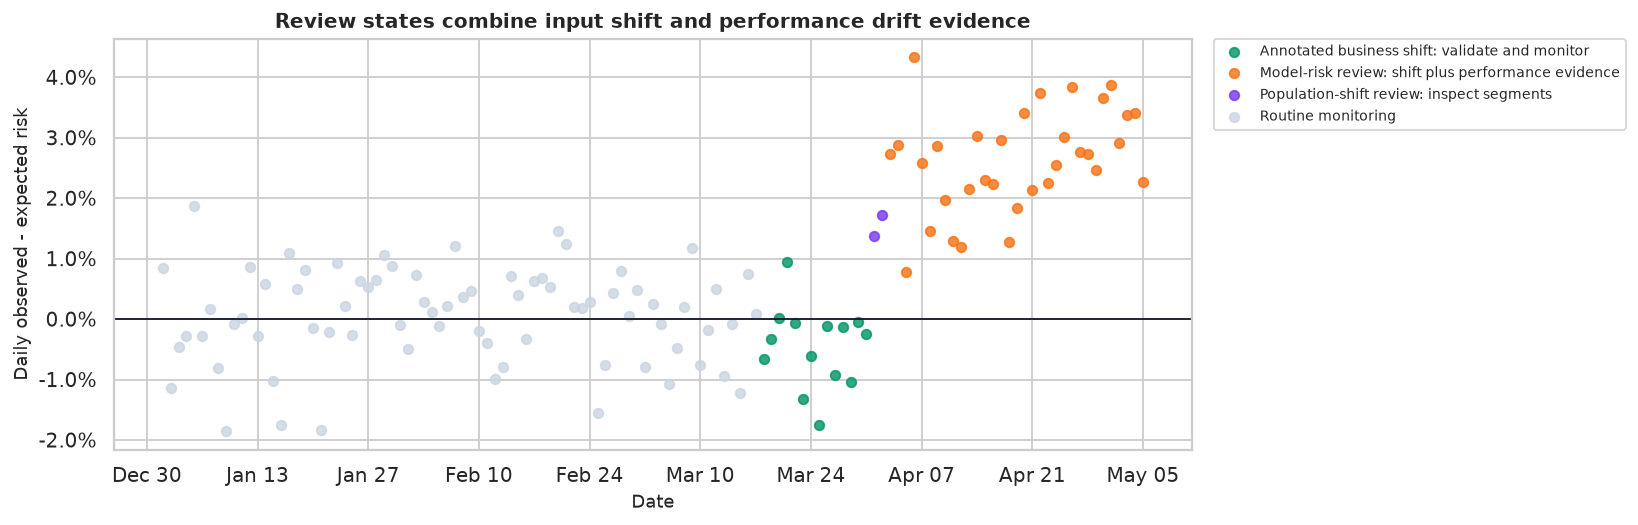

In [9]:
# Section focus: 12. Combining Evidence into Review States.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

review = daily[['date', 'day', 'period', 'cusum_alert', 'model_residual']].copy()
review = review.merge(shift_windows[['end_day', 'total_psi', 'max_ks']].rename(columns={'end_day': 'day'}), on='day', how='left')
review = review.merge(classifier_shift[['end_day', 'classifier_shift_auc']].rename(columns={'end_day': 'day'}), on='day', how='left')
review = review.merge(perf[['end_day', 'roc_auc', 'average_precision']].rename(columns={'end_day': 'day'}), on='day', how='left')
review[['total_psi', 'max_ks', 'classifier_shift_auc', 'roc_auc', 'average_precision']] = review[['total_psi', 'max_ks', 'classifier_shift_auc', 'roc_auc', 'average_precision']].ffill()

review['population_shift_review'] = (review['total_psi'] > 0.25) | (review['classifier_shift_auc'] > 0.75)
review['performance_drift_review'] = review['cusum_alert'] | (review['roc_auc'] < 0.68)
review['known_business_shift'] = review['period'].eq('wallet_launch')
review['recommended_state'] = np.select(
    [
        review['performance_drift_review'] & review['population_shift_review'],
        review['population_shift_review'] & review['known_business_shift'],
        review['population_shift_review'],
    ],
    [
        'Model-risk review: shift plus performance evidence',
        'Annotated business shift: validate and monitor',
        'Population-shift review: inspect segments',
    ],
    default='Routine monitoring',
)

state_table = review.groupby(['period', 'recommended_state']).agg(
    days=('date', 'size'),
    first_day=('date', 'min'),
    last_day=('date', 'max'),
    mean_total_psi=('total_psi', 'mean'),
    mean_classifier_auc=('classifier_shift_auc', 'mean'),
    mean_model_residual=('model_residual', 'mean'),
    mean_roc_auc=('roc_auc', 'mean'),
).reset_index()

smart_display(state_table.style.format({
    'mean_total_psi': '{:.3f}',
    'mean_classifier_auc': '{:.3f}',
    'mean_model_residual': '{:.2%}',
    'mean_roc_auc': '{:.3f}',
}, na_rep='not computed'))

fig, ax = plt.subplots(figsize=(12.8, 4.2))
state_colors = {
    'Routine monitoring': '#cbd5e1',
    'Annotated business shift: validate and monitor': PALETTE['covariate'],
    'Population-shift review: inspect segments': PALETTE['shift'],
    'Model-risk review: shift plus performance evidence': PALETTE['concept'],
}
for state, group in review.groupby('recommended_state'):
    ax.scatter(group['date'], group['model_residual'], s=28, color=state_colors[state], label=state, alpha=0.82)
ax.axhline(0, color=PALETTE['threshold'], linewidth=1.0)
ax.set_ylabel('Daily observed - expected risk')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
ax.set_xlabel('Date')
ax.set_title('Review states combine input shift and performance drift evidence')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()


This is where monitoring becomes decision science. We do not want a dashboard that says only "drift detected." We want a workflow that distinguishes business-context shift, population review, and model-risk review.

The wallet launch is a distribution shift that should be annotated and validated. The first few launch days remain in routine monitoring because the rolling seven-day shift statistics have not accumulated enough monitoring history yet. The later period combines shift with outcome evidence, so it deserves a stronger model-risk response.


## 13. Decision Memo

| Evidence | Interpretation | Recommended action |
|---|---|---|
| High PSI and high classifier-shift AUC during wallet launch | The input population changed | Annotate launch, validate affected segments, avoid panic retraining |
| Positive CUSUM on observed-minus-expected risk | The model persistently underestimates risk | Escalate model-risk review and threshold review |
| Rolling ranking quality deteriorates | The old feature-outcome relationship is weaker | Retrain or redesign features, especially for new fraud strategy |
| Shift without outcome harm | Business change or harmless domain expansion | Monitor and document, but do not treat as incident |
| Outcome harm without strong input shift | Possible hidden concept drift or data-quality issue | Inspect labels, logging, and unmeasured features |

A mature monitoring system should keep these evidence streams separate. Input drift is an early-warning signal. Outcome drift is a harm signal. Business annotations prevent false governance alarms.


In [10]:
decision_memo = pd.DataFrame([
    {
        'decision_question': 'Did the production population move?',
        'evidence': 'Total PSI and classifier two-sample AUC rise after the wallet launch.',
        'decision': 'Open a population-shift review and validate segment performance.',
    },
    {
        'decision_question': 'Is the deployed risk model underestimating chargebacks?',
        'evidence': 'Observed-minus-expected residuals accumulate in the CUSUM after the fraud-adaptation period.',
        'decision': 'Escalate model-risk review; consider threshold recalibration while retraining is prepared.',
    },
    {
        'decision_question': 'Should every drift alert trigger an incident?',
        'evidence': 'The wallet launch creates input shift before clear harm appears.',
        'decision': 'No. Annotate expected business shifts and separate them from incident response.',
    },
    {
        'decision_question': 'What should be monitored next?',
        'evidence': 'Shift is concentrated in mobile-wallet usage, order value, promo exposure, and later velocity patterns.',
        'decision': 'Track segment-level chargeback, approval, and friction outcomes for those shifted groups.',
    },
])
smart_display(decision_memo)


,decision_question,evidence,decision
0,Did the production population move?,Total PSI and classifier two-sample AUC rise after the wallet launch.,Open a population-shift review and validate segment performance.
1,Is the deployed risk model underestimating chargebacks?,Observed-minus-expected residuals accumulate in the CUSUM after the fraud-adaptation period.,Escalate model-risk review; consider threshold recalibration while retraining is prepared.
2,Should every drift alert trigger an incident?,The wallet launch creates input shift before clear harm appears.,No. Annotate expected business shifts and separate them from incident response.
3,What should be monitored next?,"Shift is concentrated in mobile-wallet usage, order value, promo exposure, and later velocity patterns.","Track segment-level chargeback, approval, and friction outcomes for those shifted groups."


Decision Memo should be read as an operations question. The practical test is whether the score points to something worth reviewing.


## 14. Key Takeaways

1. Point anomalies and change points are different problems. A change point means the data-generating process has moved.
2. CUSUM accumulates persistent evidence and is useful for detecting sustained model underestimation.
3. PSI and KS-style statistics identify which feature distributions changed, but they do not prove business harm.
4. Classifier two-sample tests can detect multivariate population shift by asking whether reference and current examples are distinguishable.
5. Delayed labels are essential for diagnosing whether input shift caused model-performance drift.
6. Monitoring systems should separate annotated business shifts, population-shift review, and model-risk escalation.


## References

- Brugman, S., Sostak, T., Patil, P., Khormali, A., Liu, R., & Dunn, R. (2022). popmon: Analysis package for dataset shift detection. *Proceedings of the 21st Python in Science Conference*, 194-201. [https://doi.org/10.25080/majora-212e5952-01d](https://doi.org/10.25080/majora-212e5952-01d)
- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys*, 41(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)
- Dockes, J., Varoquaux, G., & Poline, J.-B. (2021). Preventing dataset shift from breaking machine-learning biomarkers. *GigaScience*, 10(9). [https://doi.org/10.1093/gigascience/giab055](https://doi.org/10.1093/gigascience/giab055)
- Londschien, M., Buhlmann, P., & Kovacs, S. (2022). Random forests for change point detection. *arXiv*. [https://doi.org/10.48550/arxiv.2205.04997](https://doi.org/10.48550/arxiv.2205.04997)
- Lucas, Y., Portier, P.-E., Laporte, L., He-Guelton, L., Caelen, O., Granitzer, M., & Calabretto, S. (2019). Dataset shift quantification for credit card fraud detection. *2019 IEEE First International Conference on Artificial Intelligence and Knowledge Engineering*, 97-100. [https://doi.org/10.1109/aike.2019.00024](https://doi.org/10.1109/aike.2019.00024)
- Sugiyama, M., & Schwaighofer, A. (2008). *Dataset Shift in Machine Learning*. MIT Press. [https://doi.org/10.7551/mitpress/9780262170055.001.0001](https://doi.org/10.7551/mitpress/9780262170055.001.0001)
- Wang, H., & Xie, Y. (2023). Sequential change-point detection: Computation versus statistical performance. *Wiley Interdisciplinary Reviews: Computational Statistics*, 16(1). [https://doi.org/10.1002/wics.1628](https://doi.org/10.1002/wics.1628)
